In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 加载数据（假设数据文件为 university_rank.csv）
df = pd.read_csv('cwurData.csv')
df.head()

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012


In [2]:
# 定义特征和目标变量
features = ['quality_of_education', 'alumni_employment', 'quality_of_faculty', 
            'publications', 'influence', 'citations', 'patents']
target = 'score'

# 标准化特征
scaler = StandardScaler()
X = scaler.fit_transform(df[features])
y = df[target]

In [3]:
# 添加截距项
X = sm.add_constant(X)

# 训练模型
model = sm.OLS(y, X).fit()

# 输出回归结果
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  score   R-squared:                       0.510
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     325.3
Date:                Sun, 09 Mar 2025   Prob (F-statistic):               0.00
Time:                        11:56:02   Log-Likelihood:                -6845.5
No. Observations:                2200   AIC:                         1.371e+04
Df Residuals:                    2192   BIC:                         1.375e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.7984      0.116    411.835      0.0

In [4]:
# 提取系数和 p 值
coef_df = pd.DataFrame({
    'Feature': ['Intercept'] + features,
    'Coefficient': model.params,
    'P-value': model.pvalues
})

print(coef_df)

                    Feature  Coefficient       P-value
const             Intercept    47.798395  0.000000e+00
x1     quality_of_education    -0.435159  3.250527e-02
x2        alumni_employment    -1.015455  1.413123e-10
x3       quality_of_faculty    -3.953923  1.318803e-78
x4             publications    -0.227737  4.018072e-01
x5                influence    -0.075914  7.809501e-01
x6                citations    -0.102966  6.657502e-01
x7                  patents    -0.461987  4.761625e-03


In [5]:
# 计算方差膨胀因子 (VIF)
vif_data = pd.DataFrame()
vif_data["feature"] = features
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]  # 跳过截距项

print(vif_data)

                feature       VIF
0  quality_of_education  3.071086
1     alumni_employment  1.842628
2    quality_of_faculty  3.035662
3          publications  5.475449
4             influence  5.531072
5             citations  4.216485
6               patents  1.984503


In [6]:
print(f"R-squared: {model.rsquared:.3f}")

R-squared: 0.510


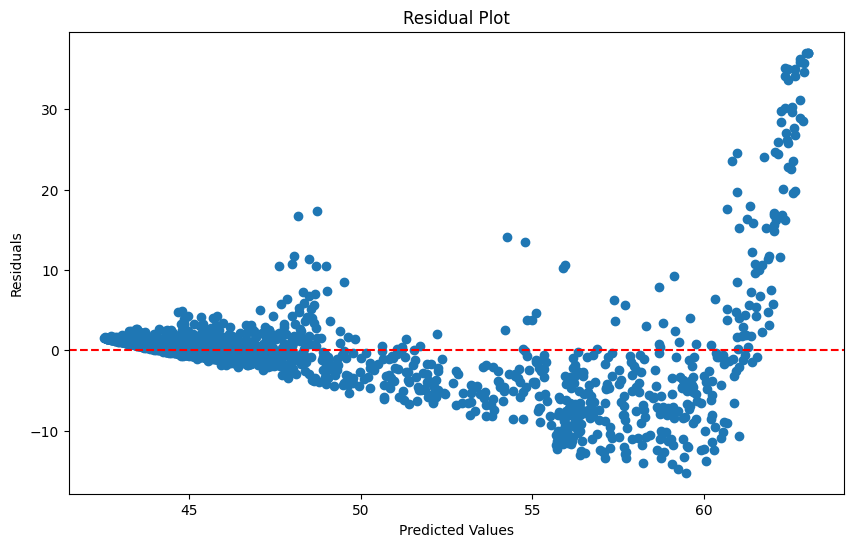

In [7]:
# 绘制残差分布图
plt.figure(figsize=(10, 6))
plt.scatter(model.predict(), model.resid)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()